In [8]:
print("HELLO WORLD")

HELLO WORLD


**Dataset Configuration:**

**data.yaml file**

In [ ]:
import yaml
import os

# Define the paths relative to the Kaggle working directory
DATASET_ROOT = 'paste the path of dataset folder'

# 1. Define the content of your data_merged.yaml file (UPDATED FOR 3 CLASSES)
yaml_data = dict(
    path=DATASET_ROOT,
    train='train/images',
    val='val/images',
    test='test/images',
    nc=3,  # ✅ Updated number of classes to 3
    names=['dot', 'scratch', 'crack']  # ✅ Added 'crack' (Class ID 2)
)

# 2. Write the YAML file to the current directory
YAML_FILENAME = 'data.yaml'
with open(YAML_FILENAME, 'w') as file:
    yaml.dump(yaml_data, file, default_flow_style=False)

print(f"--- Created {YAML_FILENAME} locally ---")
print(open(YAML_FILENAME).read())

**Environment Setup**

**Install & Import lib**

In [3]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 96.8 MB/s eta 0:00:00:00:010:01
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you 

In [4]:
import os
import torch
from ultralytics import YOLO

# 1. Purge active VRAM fragments from prior operations
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


**Model Training:**

In [6]:

DATA_YAML_PATH = "/kaggle/working/data.yaml"

print("🔄 INITIALIZING ATTENTION-CENTRIC YOLO12-LARGE FRAMEWORK...")

# We build the architecture layout directly from the YOLO12-Large schema definition,
# then load the pre-trained flagship weights into the structural pipeline.
# FIX: Change 'yolov12l.pt' to 'yolo12l.pt'
model = YOLO("yolo12l.yaml").load("yolo12l.pt")

print("🚀 LAUNCHING STABILIZED HIGH-PRECISION YOLO12-LARGE RUN ON .TXT LABELS")

model.train(
    data=DATA_YAML_PATH,    
    epochs=32,              
    imgsz=512,              
    batch=12,               # Mapped to maximize your T4 card without overloading
    device=0,               
    workers=2,              
    optimizer='AdamW',      # Excellent for attention-based weight adjustments
    lr0=0.0001,             # STABILIZED: Safe learning rate to stop weight warping
    mosaic=0.0,
    close_mosaic=0,     # BULLETPROOF: Restricts gradient steps to kill NaN explosions
    amp=False,              # FORCED FP32: Disables mixed precision to prevent numeric overflows!
    plots=True,             
    save=True,              
    project="defect_project", 
    name="YOLO12_Large"
)

# 2. Automatically generate the post-training project report metrics
print("\n📝 Training complete. Initiating final verification evaluation splits...")
val_results = model.val(data=DATA_YAML_PATH, split="val", imgsz=512)
print("🎉 Evaluation matrices saved to your runs directory.")

🔄 INITIALIZING ATTENTION-CENTRIC YOLO12-LARGE FRAMEWORK...
Transferred 1245/1245 items from pretrained weights
🚀 LAUNCHING STABILIZED HIGH-PRECISION YOLO12-LARGE RUN ON .TXT LABELS
Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=12, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=0, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data_merged.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=32, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0,

**Validation Score**

In [7]:
# 2. Automatically generate the post-training project report metrics
print("\n📝 Training complete. Initiating final verification evaluation splits...")
val_results = model.val(data="/kaggle/working/data_merged.yaml", split="val", imgsz=512)
print("🎉 Evaluation matrices saved to your runs directory.")


📝 Training complete. Initiating final verification evaluation splits...
Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO12l summary (fused): 283 layers, 26,341,385 parameters, 0 gradients, 88.6 GFLOPs
val: Fast image access ✅ (ping: 1.2±0.5 ms, read: 1187.6±937.9 MB/s, size: 1124.0 KB)
val: Scanning /kaggle/input/datasets/malikmuqeet/project-dataset/val/labels... 303 images, 131 backgrounds, 3 corrupt: 100% ━━━━━━━━━━━━ 306/306 376.8it/s 0.8s0.0s
val: /kaggle/input/datasets/malikmuqeet/project-dataset/val/images/Datacluster Cracked Screen (117).jpg: ignoring corrupt image/label: [Errno 30] Read-only file system: '/kaggle/input/datasets/malikmuqeet/project-dataset/val/images/Datacluster Cracked Screen (117).jpg'
val: /kaggle/input/datasets/malikmuqeet/project-dataset/val/images/Datacluster Cracked Screen (143).jpg: ignoring corrupt image/label: [Errno 30] Read-only file system: '/kaggle/input/datasets/malikmuqeet/project-dataset/val/images/Dataclu

**Archiving Results:**

In [ ]:
import shutil
import os

YOLO12_OUTPUT_DIR = " ADD path to output foldr"
ZIP_DESTINATION_PATH = "/kaggle/working/YOLO12_Large_Final_Results"

if os.path.exists(YOLO12_OUTPUT_DIR):
    print("⚡ Compressing YOLO12 attention maps, weights, and performance charts...")
    shutil.make_archive(ZIP_DESTINATION_PATH, 'zip', YOLO12_OUTPUT_DIR)
    print(f"🎉 SUCCESS! Target Archive Ready at: {ZIP_DESTINATION_PATH}.zip")
else:
    print("❌ Error: Could not verify YOLO12 output run directories.")

**TEST Split Evaluation Score**

In [5]:
import pandas as pd

# 1. Load your best model
model = YOLO('Add path of trained model best.pt') 

# 2. Run validation on the TEST split
# This generates the full metrics object
results = model.val(data='/kaggle/working/data_merged.yaml', split='test', imgsz=512)

# 3. Extract and Format Per-Class Results
class_names = model.names
stats = []

for i, name in class_names.items():
    # Each class_result(i) returns [Precision, Recall, mAP50, mAP50-95]
    p, r, ap50, ap95 = results.box.class_result(i)
    stats.append({
        "Class": name,
        "Precision": f"{p:.4f}",
        "Recall": f"{r:.4f}",
        "mAP50": f"{ap50:.4f}",
        "mAP50-95": f"{ap95:.4f}"
    })

# 4. Create a clean Table for your report
df_test = pd.DataFrame(stats)

print("\n" + "="*50)
print("📊 FINAL TEST SET PERFORMANCE (PER CLASS)")
print("="*50)
print(df_test.to_string(index=False))

print("\n" + "="*50)
print("🏆 OVERALL SUMMARY METRICS")
print("="*50)
print(f"Overall mAP50:    {results.box.map50:.4f}")
print(f"Overall mAP50-95: {results.box.map:.4f}")
print(f"Mean Precision:   {results.box.mp:.4f}")
print(f"Mean Recall:      {results.box.mr:.4f}")
print(f"Model Fitness:    {results.fitness:.4f}")
print("="*50)

Ultralytics 8.4.74 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO12l summary (fused): 283 layers, 26,341,385 parameters, 0 gradients, 88.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 60.2±43.4 MB/s, size: 1069.0 KB)
val: Scanning /kaggle/input/datasets/malikmuqeet/project-dataset/test/labels... 302 images, 142 backgrounds, 6 corrupt: 100% ━━━━━━━━━━━━ 308/308 195.2it/s 1.6s0.1s
val: /kaggle/input/datasets/malikmuqeet/project-dataset/test/images/Datacluster Cracked Screen (196).jpg: ignoring corrupt image/label: [Errno 30] Read-only file system: '/kaggle/input/datasets/malikmuqeet/project-dataset/test/images/Datacluster Cracked Screen (196).jpg'
val: /kaggle/input/datasets/malikmuqeet/project-dataset/test/images/Datacluster Cracked Screen (197).jpg: ignoring corrupt image/label: [Errno 30] Read-only file system: '/kaggle/input/datasets/malikmuqeet/project-dataset/test/images/Datacluster Cracked Screen (197).jpg'
val: /kaggle/input/datasets/malikmuqeet/

**Img Testing**


image 1/4 /kaggle/input/datasets/malikmuqeet/project-dataset/test/images/Professional_smartphone_mockup_screen_showing_mute_20251213_143557_seed_1246283001_image_3.png: 512x512 (no detections), 40.6ms
image 2/4 /kaggle/input/datasets/malikmuqeet/project-dataset/test/images/Sta_0272_jpg.rf.FOtXrZ5HzYsFl9dEhqci.jpg: 512x512 4 dots, 40.6ms
image 3/4 /kaggle/input/datasets/malikmuqeet/project-dataset/test/images/Front_angle_smartphone_screen_image_with_smooth_li_20251213_135720_seed_1634702486_image_1.png: 512x512 (no detections), 28.5ms
image 4/4 /kaggle/input/datasets/malikmuqeet/project-dataset/test/images/Scr_0081_jpg.rf.86b199f97d17d3454aeb3b610e3cafac.jpg: 512x512 1 scratch, 28.4ms
Speed: 1.3ms preprocess, 34.5ms inference, 1.3ms postprocess per image at shape (1, 3, 512, 512)
--- Inference Results ---
Test Image 1: (no detections), 
Test Image 2: 4 dots, 
Test Image 3: (no detections), 
Test Image 4: 1 scratch, 

--- Displaying Result Images in One Row ---


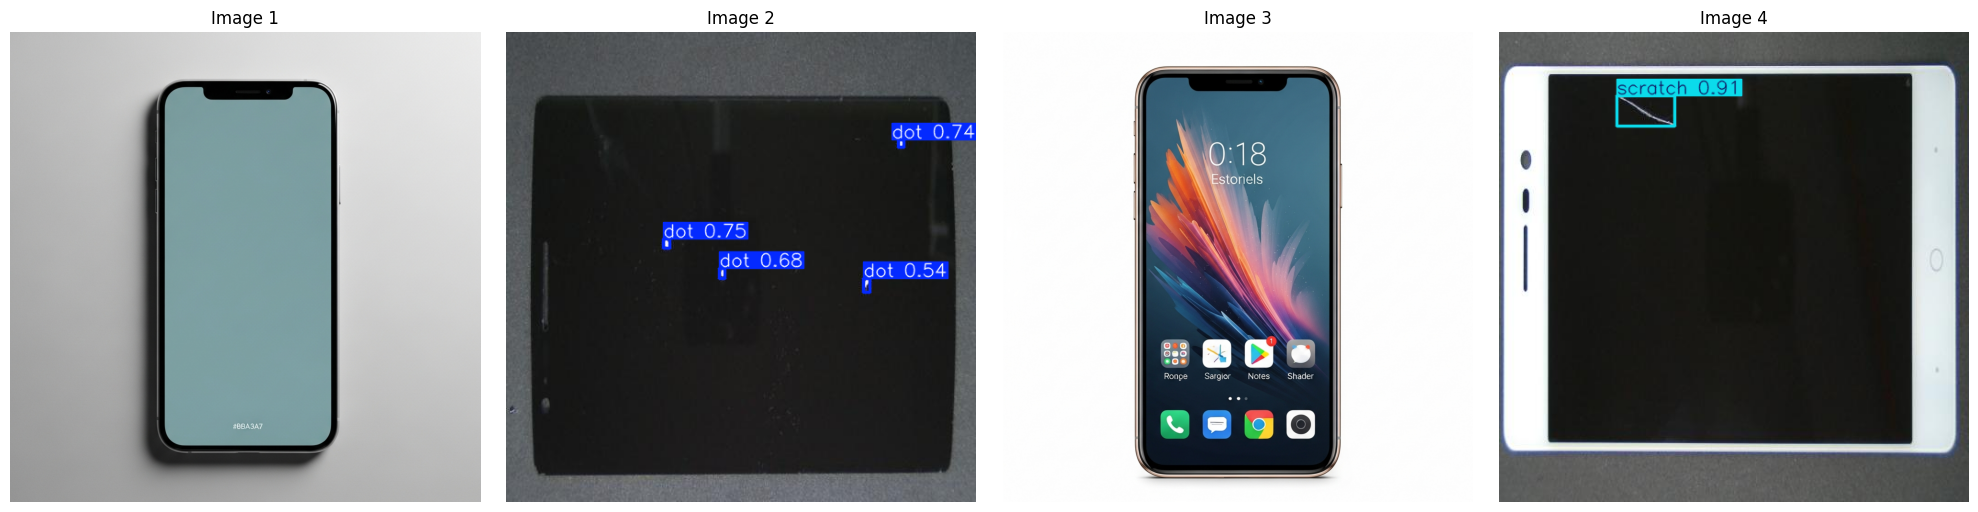

In [6]:
import os
import random
import matplotlib.pyplot as plt
import cv2
from ultralytics import YOLO

# 1. Load the model
model = YOLO('Add path of trained model best.pt') 
test_dir = 'Add path of test folder img'

# 2. Get 4 random images
all_images = [f for f in os.listdir(test_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
random_images_paths = [os.path.join(test_dir, img) for img in random.sample(all_images,4)]

# 3. Run inference
results = model(random_images_paths)

# 4. Display inference summary text
print("--- Inference Results ---")
for i, res in enumerate(results):
    print(f"Test Image {i+1}: {res.verbose()}")

# 5. Display the result images in a single row
print("\n--- Displaying Result Images in One Row ---")
fig, axes = plt.subplots(1, 4, figsize=(20, 5)) # 1 row, 4 columns

for i, res in enumerate(results):
    # Plot the result
    res_plotted = res.plot()
    
    # Convert BGR to RGB
    res_plotted = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)
    
    axes[i].imshow(res_plotted)
    axes[i].set_title(f"Image {i+1}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display

# Define the path to your rescue run results
results_dir = 'Add trained foldr path'

def display_result(filename, title):
    path = os.path.join(results_dir, filename)
    if os.path.exists(path):
        print(f"\n--- {title} ---")
        img = Image.open(path)
        display(img)
    else:
        print(f"⚠️ {filename} not found yet. Training might still be finalizing.")

# 1. Training & Validation Curves (Loss and mAP)
# This shows the mAP climbing from 0.35 to 0.79
display_result('results.png', 'Training Progress (mAP & Loss)')

# 2. Confusion Matrix
# This proves the model knows 'Dot' vs 'Scratch'
# display_result('confusion_matrix.png', 'Class Accuracy: Dot vs Scratch')

# 3. Normalized Confusion Matrix (Percentage-based)
display_result('confusion_matrix_normalized.png', 'Accuracy Percentages')